<a href="https://colab.research.google.com/github/smitp2705/data_pre_pr2/blob/main/Project_2_PRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_excel("/content/patient_health_records_1000.xlsx")
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,69.0,Male,North,21.4,277.6,209.8,125.3,1
1,P0002,81.0,Female,South,27.1,118.6,181.4,97.1,0
2,P0003,72.0,Male,South,26.9,275.4,214.6,120.8,1
3,P0004,70.0,Male,North,23.3,113.3,233.2,139.5,1
4,P0005,21.0,Female,North,28.0,95.6,NaN,104.9,0


In [ ]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1000 non-null   object 
 1   age             950 non-null    float64
 2   gender          960 non-null    object 
 3   region          960 non-null    object 
 4   bmi             950 non-null    float64
 5   blood_pressure  1000 non-null   float64
 6   cholesterol     950 non-null    float64
 7   glucose         950 non-null    float64
 8   disease_risk    1000 non-null   int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 70.4+ KB


,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,950.000000,950.000000,1000.000000,950.00000,950.000000,1000.000000
mean,53.292632,27.329684,128.599100,203.82200,105.641579,0.350000
std,21.030778,6.779824,24.423024,47.71054,52.390979,0.477208
min,18.000000,8.500000,81.000000,78.20000,14.400000,0.000000
25%,34.000000,23.500000,115.475000,174.97500,82.725000,0.000000
50%,53.000000,27.150000,126.000000,201.45000,99.650000,0.000000
75%,72.000000,30.600000,136.425000,228.00000,116.275000,1.000000
max,89.000000,69.300000,277.600000,472.80000,476.000000,1.000000


In [ ]:
missing_values = df.isnull().sum()

missing_percent = round(
    (df.isnull().sum()/len(df))*100,
    2
)

missing_report = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing %": missing_percent
})

missing_report

,Missing Count,Missing %
patient_id,0,0.0
age,50,5.0
gender,40,4.0
region,40,4.0
bmi,50,5.0
blood_pressure,0,0.0
cholesterol,50,5.0
glucose,50,5.0
disease_risk,0,0.0


In [ ]:
numerical_cols = [
    'age',
    'bmi',
    'cholesterol',
    'glucose'
]

mean_imputer = SimpleImputer(strategy='mean')

df_simple_num = df.copy()

df_simple_num[numerical_cols] = mean_imputer.fit_transform(
    df_simple_num[numerical_cols]
)

In [ ]:
region_imputer = SimpleImputer(strategy='most_frequent')

df_simple_num['region'] = region_imputer.fit_transform(
    df_simple_num[['region']]
).ravel()

In [ ]:
gender_imputer = SimpleImputer(strategy='most_frequent')

df_simple_num['gender'] = gender_imputer.fit_transform(
    df_simple_num[['gender']]
).ravel()

In [ ]:
df_random = df.copy()
cols_missing = [
    'age',
    'gender',
    'region',
    'bmi',
    'cholesterol',
    'glucose'
]
for col in cols_missing:
    df_random[col+'_missing'] = np.where(
        df_random[col].isnull(),
        1,
        0
    )

In [ ]:
for col in cols_missing:

    random_sample = (
        df_random[col]
        .dropna()
        .sample(
            df_random[col].isnull().sum(),
            replace=True,
            random_state=42
        )
    )

    random_sample.index = (
        df_random[df_random[col].isnull()].index
    )

    df_random.loc[
        df_random[col].isnull(),
        col
    ] = random_sample

In [ ]:
df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,69.0,Male,North,21.4,277.6,209.8,125.3,1
1,P0002,81.0,Female,South,27.1,118.6,181.4,97.1,0
2,P0003,72.0,Male,South,26.9,275.4,214.6,120.8,1
3,P0004,70.0,Male,North,23.3,113.3,233.2,139.5,1
4,P0005,21.0,Female,North,28.0,95.6,NaN,104.9,0


In [ ]:
df_knn = df.copy()

num_cols = [
    'age',
    'bmi',
    'blood_pressure',
    'cholesterol',
    'glucose'
]

knn = KNNImputer(n_neighbors=5)

df_knn[num_cols] = knn.fit_transform(
    df_knn[num_cols]
)

In [ ]:
df_knn['gender'].fillna(
    df_knn['gender'].mode()[0],
    inplace=True
)

df_knn['region'].fillna(
    df_knn['region'].mode()[0],
    inplace=True
)

In [ ]:
df_mice = df.copy()

num_cols = [
    'age',
    'bmi',
    'blood_pressure',
    'cholesterol',
    'glucose'
]

mice = IterativeImputer(
    random_state=42
)

df_mice[num_cols] = mice.fit_transform(
    df_mice[num_cols]
)

df_mice['gender'].fillna(
    df_mice['gender'].mode()[0],
    inplace=True
)

df_mice['region'].fillna(
    df_mice['region'].mode()[0],
    inplace=True
)

In [ ]:
outlier_cols = [
    'bmi',
    'blood_pressure',
    'cholesterol',
    'glucose'
]

In [ ]:
df_zscore = df_mice.copy()

z_chol = np.abs(
    zscore(df_zscore['cholesterol'])
)

z_glucose = np.abs(
    zscore(df_zscore['glucose'])
)

df_zscore = df_zscore[
    (z_chol < 3) &
    (z_glucose < 3)
]

print(df_zscore.shape)

(957, 9)


In [ ]:
df_iqr = df_mice.copy()

Q1 = df_iqr['bmi'].quantile(0.25)
Q3 = df_iqr['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df_iqr = df_iqr[
    (df_iqr['bmi'] >= lower) &
    (df_iqr['bmi'] <= upper)
]

print(df_iqr.shape)

(962, 9)


In [ ]:
df_percentile = df_mice.copy()

for col in outlier_cols:

    lower = df_percentile[col].quantile(0.01)
    upper = df_percentile[col].quantile(0.99)

    df_percentile[col] = np.clip(
        df_percentile[col],
        lower,
        upper
    )

In [ ]:
df_winsor = df_mice.copy()

for col in outlier_cols:

    lower = df_winsor[col].quantile(0.05)
    upper = df_winsor[col].quantile(0.95)

    df_winsor[col] = np.where(
        df_winsor[col] < lower,
        lower,
        df_winsor[col]
    )

    df_winsor[col] = np.where(
        df_winsor[col] > upper,
        upper,
        df_winsor[col]
    )

In [ ]:
print("Original Shape")
print(df.shape)

print("Z-score Shape")
print(df_zscore.shape)

print("IQR Shape")
print(df_iqr.shape)

print("Percentile Shape")
print(df_percentile.shape)

print("Winsorized Shape")
print(df_winsor.shape)

Original Shape
(1000, 9)
Z-score Shape
(957, 9)
IQR Shape
(962, 9)
Percentile Shape
(1000, 9)
Winsorized Shape
(1000, 9)


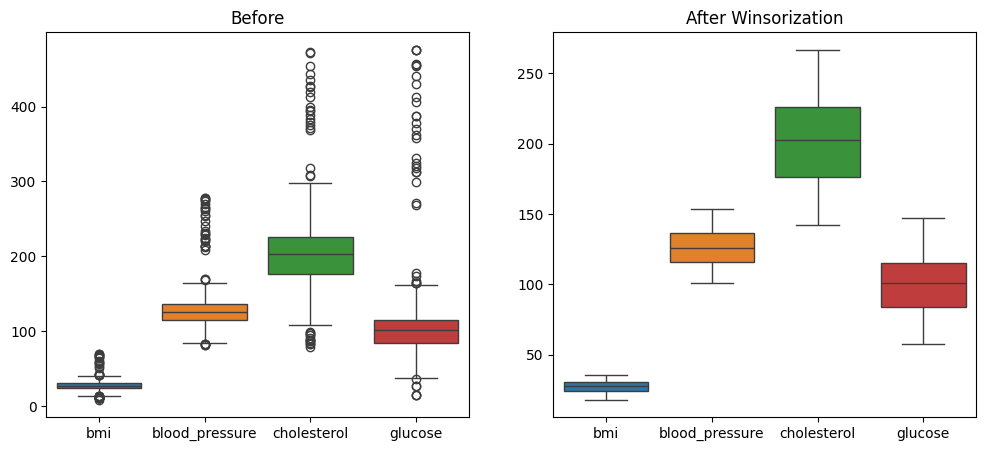

In [ ]:
fig, ax = plt.subplots(
    1,2,
    figsize=(12,5)
)

sns.boxplot(
    data=df_mice[outlier_cols],
    ax=ax[0]
)

ax[0].set_title("Before")

sns.boxplot(
    data=df_winsor[outlier_cols],
    ax=ax[1]
)

ax[1].set_title("After Winsorization")

plt.show()

**Final Clean Dataset**

In [ ]:
final_df = df_winsor.copy()
final_df.isnull().sum()

,0
patient_id,0
age,0
gender,0
region,0
bmi,0
blood_pressure,0
cholesterol,0
glucose,0
disease_risk,0


In [ ]:
final_df.describe()

,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.292771,27.069152,126.351300,201.950126,100.112353,0.350000
std,20.497789,4.733182,14.233292,34.048829,23.440773,0.477208
min,18.000000,17.895000,101.000000,142.190000,57.455000,0.000000
25%,35.750000,23.700000,115.475000,176.550000,83.925000,0.000000
50%,53.287472,27.300000,126.000000,202.950000,100.900000,0.000000
75%,71.000000,30.500000,136.425000,226.300000,115.300000,1.000000
max,89.000000,35.510000,153.210000,266.915000,146.925000,1.000000


In [ ]:
final_df.to_csv(
    "cleaned_patient_records.xlsx",
    index=False
)

**Missing** **Value** **Analysis**

| Column      | Missing Handling |
| ----------- | ---------------- |
| Age         | MICE             |
| Gender      | Most Frequent    |
| Region      | Most Frequent    |
| BMI         | MICE             |
| Cholesterol | MICE             |
| Glucose     | MICE             |


**Outlier Analysis**

| Column         | Method                  |
| -------------- | ----------------------- |
| BMI            | IQR                     |
| Blood Pressure | Winsorization           |
| Cholesterol    | Z-Score + Winsorization |
| Glucose        | Z-Score + Winsorization |


Report Questions Answers

Q1. Which imputation strategy was most effective?

MICE (Multiple Imputation by Chained Equations) was the most effective because it uses relationships among variables rather than replacing values with a simple mean or mode. This preserves data variability and reduces bias.

Q2. Which outlier method preserved data quality best?

Winsorization preserved data quality best because it capped extreme values instead of deleting records. This retained all observations while reducing the influence of outliers.

Q3. How did data cleaning improve usability?
Removed missing values.
Reduced noise from extreme outliers.
Improved feature consistency.
Produced a machine-learning-ready dataset.
Increased model reliability and predictive performance.